# Test Landmarks

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

from itertools import combinations
import face_recognition

2023-05-05 11:37:23.393904: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-05 11:37:23.451478: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-05 11:37:24.293267: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
TESTING_COHERENCE_LOSS = "l1"
TESTING_MAIN_LOSS = "l1"

# Dimensions
BATCH_SIZE = 20
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 100000

LAMBDA1 = 1000
LAMBDA2 = 200

VIDEOS_FOLDER = 'mug64'

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
videos_path = list(Path(f'../data/{VIDEOS_FOLDER}/').glob('**/*.npy'))

In [6]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

print(len(train_paths))
print(len(test_paths))

722
310


In [7]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        #pick a random video index
        self.current_video_index = np.random.randint(0, self.n)
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self):
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [8]:
train_generator = FrameDataGenerator(train_paths, batch_size=20)
test_generator = FrameDataGenerator(test_paths, batch_size=20)

previous_frame, current_frame, next_frame = next(train_generator)
previous_frame2, current_frame2, next_frame2 = next(train_generator)
previous_frame3, current_frame3, next_frame3 = next(train_generator)
previous_frame4, current_frame4, next_frame4 = next(train_generator)
print(previous_frame.shape)
print(current_frame.shape)
print(next_frame.shape)

print(train_generator.current_video_index)
print(train_generator.current_frame_index)
print(train_generator.current_video.shape)

(20, 64, 64, 3)
(20, 64, 64, 3)
(20, 64, 64, 3)
0
4
(67, 64, 64, 3)


In [9]:
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
#https://github.com/kipr/opencv/blob/master/data/haarcascades/haarcascade_frontalface_default.xml
HAARCASCADE_PATH = DATA_PATH / 'opencv' / 'haarcascade_frontalface_default.xml'
# https://github.com/opencv/opencv_3rdparty/tree/contrib_face_alignment_20170818
KAZEMI_MODEL_PATH = DATA_PATH / 'opencv' / 'face_landmark_model.dat'


2023-05-05 11:37:29.042297: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13876 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


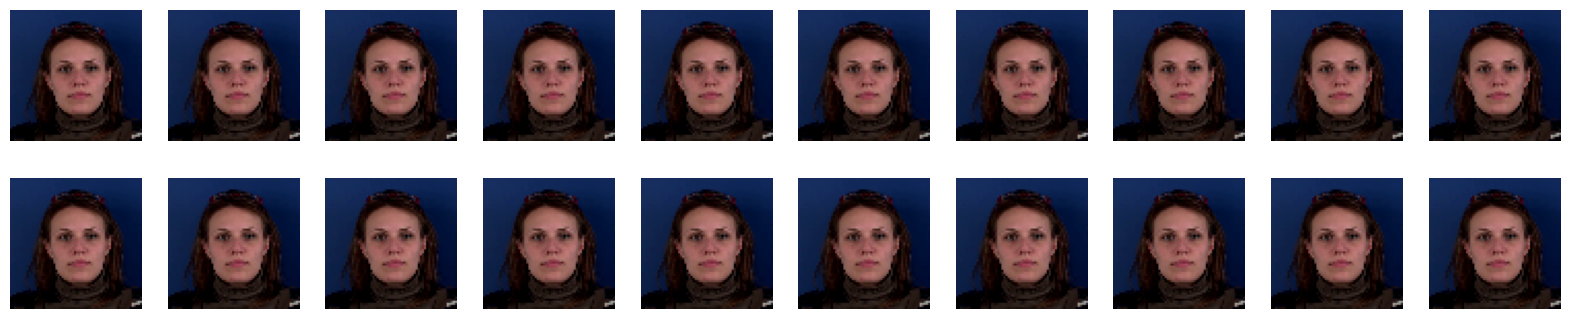

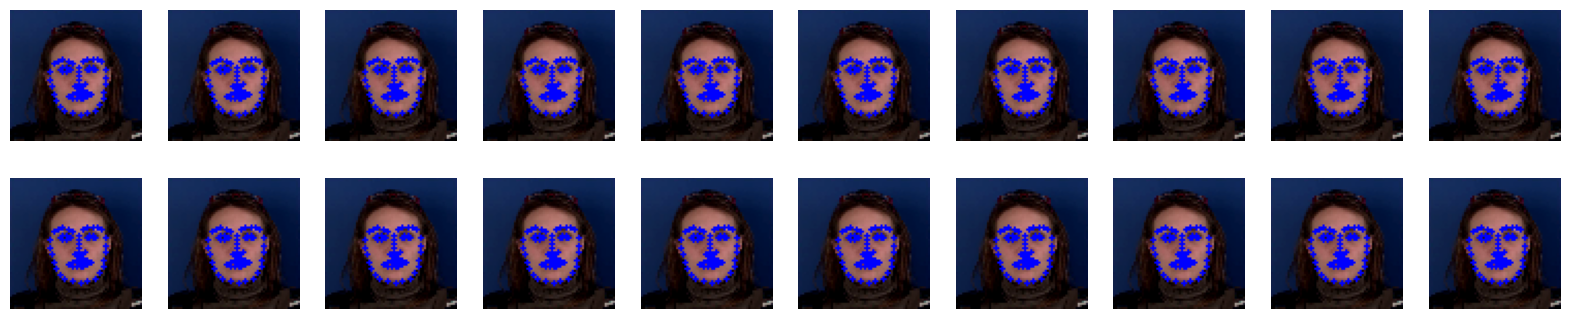

In [10]:
out_frames = []
out_landmarks = []

for image in current_frame:
    
    image =  normalized_sequence_to_images(image)
    image = np.array(image, dtype=np.uint8)

    bboxes = face_recognition.api.face_locations(image)
    faces = face_recognition.api._raw_face_landmarks(face_image=image)
    landmarks = np.array([(p.x, p.y) for p in faces[0].parts()])
    out_landmarks.append(landmarks)
                
    if len(faces) > 0:
      for l in faces[0].parts():
        cv2.circle(image, (int(l.x), int(l.y)), 1, (0, 0, 255), -1)
    else:
      print("No Face Detected")
     
    out_frames.append(image)
 
out_frames = np.array(out_frames)
out_landmarks = np.array(out_landmarks)

plot_normalized_sequence(current_frame)
plot_sequence(out_frames)

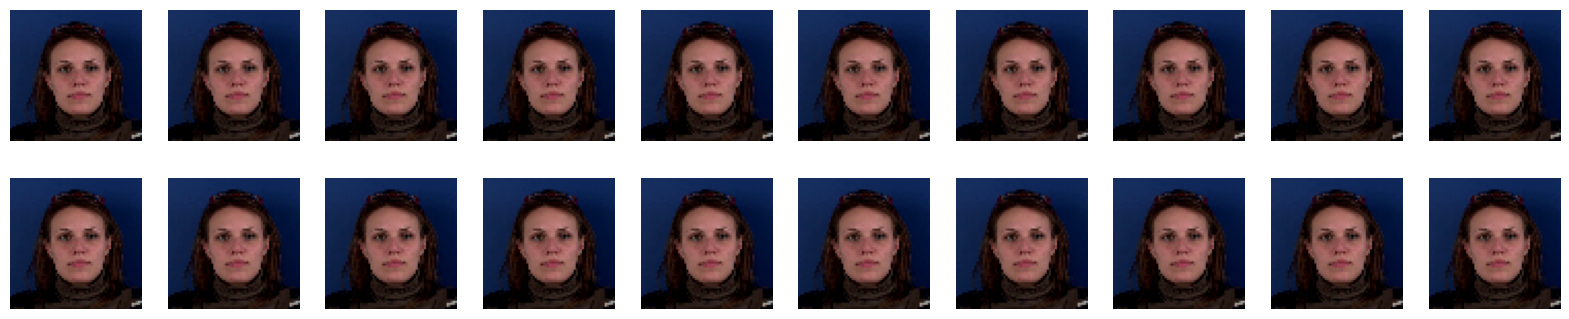

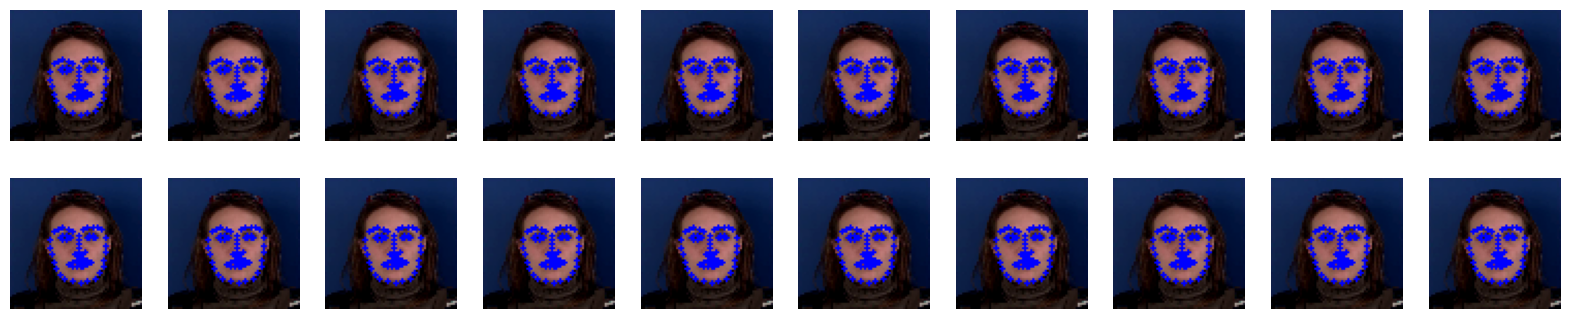

In [11]:
out_frames2 = []
out_landmarks2 = []

for image in next_frame4:
    
    image =  normalized_sequence_to_images(image)
    image = np.array(image, dtype=np.uint8)

    bboxes = face_recognition.api.face_locations(image)
    faces = face_recognition.api._raw_face_landmarks(face_image=image)
    landmarks = np.array([(p.x, p.y) for p in faces[0].parts()])
    out_landmarks2.append(landmarks)
                
    if len(faces) > 0:
      for l in faces[0].parts():
        cv2.circle(image, (int(l.x), int(l.y)), 1, (0, 0, 255), -1)
    else:
      print("No Face Detected")
     
    out_frames2.append(image)
 
out_frames = np.array(out_frames)
out_landmarks = np.array(out_landmarks)

plot_normalized_sequence(next_frame4)
plot_sequence(out_frames)

In [12]:
out_landmarks.shape

(20, 68, 2)

In [13]:
# from numba import cuda
# import numpy as np

# def cross(p0, p1, p2):
#     return not (((p1[0] - p0[0]) * (p2[1] - p1[1]) - (p2[0] - p1[0]) * (p1[1] - p0[1])) > 0)


# def whetherInTrianglesSpecial(ps, p):
#     same = [False] * 3
#     same[0] = cross(p, ps[:2], ps[2:])
#     same[1] = cross(p, ps[2:], ps[4:])
#     same[2] = cross(p, ps[4:], ps[:2])
#     return same[0] == same[1] and same[0] == same[2]

# def interpolation(triangle, triangle_value, p):
#     x01 = p[0] - triangle[0]
#     x21 = triangle[2] - triangle[0]
#     x31 = triangle[4] - triangle[0]
#     y01 = p[1] - triangle[1]
#     y21 = triangle[3] - triangle[1]
#     y31 = triangle[5] - triangle[1]
#     tmp1 = (x21 * y31 - y21 * x31)
#     tmp2 = (y31 * x21 - x31 * y21)
#     u = (x01 * y31 - y01 * x31) / tmp1
#     v = (y01 * x21 - x01 * y21) / tmp2
#     q = 1.0 - u - v
#     return q * triangle_value[0] + u * triangle_value[2] + v * triangle_value[4], q * triangle_value[1] + u * triangle_value[3] + v * triangle_value[5]


# @cuda.jit
# def calcuDeformationMap(triangles, disps, triangle_size, map_width, map_height, batch_size, dispMap_out):
#     w = cuda.grid(1)
#     h = cuda.grid(2)
#     triangle = cuda.grid(3)
#     triangles_cache = cuda.shared.array((6,), dtype=float32)
#     disps_cache = cuda.shared.array((6,), dtype=float32)
#     if threadIdx.x == 0 and threadIdx.y == 0:
#         triangles_cache[:] = triangles[6*triangle:6*triangle+6]
#         disps_cache[:] = disps[6*triangle:6*triangle+6]
#     cuda.syncthreads()
#     i_h = h
#     i_w = w
#     i_batch = 0
#     i_triangle = threadIdx.z
#     if triangle < triangle_size:
#         index = i_batch * map_width * map_height + i_h * map_width + i_w
#         p0 = np.array([i_w, i_h], dtype=np.float32)
#         triangle_index = 6 * (i_triangle + i_batch * triangle_size)
#         if whetherInTrianglesSpecial(triangles_cache[triangle_index:triangle_index+6], p0):
#             dispMap_out[2*index:2*index+2] = interpolation(
#                 triangles_cache[triangle_index:triangle_index+6], 
#                 disps_cache[triangle_index:triangle_index+6], 
#                 p0)


In [14]:
import cupy as cp
import math
from scipy.spatial import Delaunay
import itertools

def pushTriangles(land, index, width, height):
    land=land.reshape([land.shape[0],-1,2])
    triangles=cp.zeros([land.shape[0],len(index),2],cp.float32)
    triangles[:,:,0]=land[:,index,0]*width
    triangles[:,:,1]=land[:,index,1]*height
    return triangles

def calcuTrans(land, p_ref):
    left_eye_index = 39
    right_eye_index = 42
    trans = cp.zeros([land.shape[0], 2], cp.float32)
    land = land.reshape([land.shape[0], -1, 2])
    trans[:, 0] = ((land[:, left_eye_index, 0] + land[:, right_eye_index, 0]) / 2.0 - p_ref[0])
    trans[:, 1] = ((land[:, left_eye_index, 1] + land[:, right_eye_index, 1]) / 2.0 - p_ref[1])
    return trans

def centourLandmarks(land, trans):
    land=land.reshape([land.shape[0],-1,2])
    land_out=cp.array(land)
    for pp in range(0,land.shape[0]):
        land_out[pp,:,:]=land[pp,:,:]-trans[pp]
    return land_out

def calcuLineK(p1, p2):
    direct=cp.zeros([p1.shape[0],2],cp.float32)
    k=(p2[:,1]-p1[:,1])/(p2[:,0]-p1[:,0])
    c=cp.sqrt(k**2+1)
    direct[:,0]=1.0/c
    direct[:,1]=k/c
    return direct

def calcuIncludeAngle(direct1, direct2):
    cos=direct1[:,0]*direct2[:,0]+direct1[:,1]*direct2[:,1]
    return cos

def cross(da, db):
    return da[:,0]*db[:,1]-da[:,1]*db[:,0]

def rotation(land, sin, cos):
    out=np.zeros(land.shape,np.float32)
    for pp in range(0,land.shape[0]):
        out[pp,:,0]=cos[pp]*land[pp,:,0]-sin[pp]*land[pp,:,1]
        out[pp,:,1]=cos[pp]*land[pp,:,1]+sin[pp]*land[pp,:,0]
    return out

def alignedRotation2D(land, p_ref, land_ref=None):
    land=land.reshape([land.shape[0],-1,2])
    dirct_tmp = (land[:,27,:]-land[:,8,:])
    p1 = np.array([0, 0], np.float32).reshape([1,-1])
    p1 = np.tile(p1, [land.shape[0],1])
    p2 = dirct_tmp[:,::-1]
    p2[:,0] = -p2[:,0]
    if land_ref is None:
        p_ref1 = np.array([-1, 0], np.float32).reshape([1,-1])
        p_ref2 = np.array([1, 0], np.float32).reshape([1,-1])
        p_ref1 = np.tile(p_ref1, [land.shape[0],1])
        p_ref2 = np.tile(p_ref2, [land.shape[0],1])
    else:
        land_ref=land_ref.reshape([land.shape[0],-1,2])
        dirct_ref_tmp = (land_ref[:,27,:] - land_ref[:,8,:])
        p_ref1 = np.array([0, 0], np.float32).reshape([1,-1])
        p_ref1 = np.tile(p_ref1, [land_ref.shape[0],1])
        p_ref2 = dirct_ref_tmp[:,::-1]
        p_ref2 = -p_ref2[:,0]
        
    direct=calcuLineK(p1,p2)
    direct_ref=calcuLineK(p_ref1,p_ref2)
    cos=calcuIncludeAngle(direct,direct_ref)
    cr=cross(direct,direct_ref)
    sin=np.sqrt(np.abs(1-cos**2))
    for i in range(0,cr.shape[0]):
        if cr[i]<0:
            sin[i]=-sin[i]
    p_ref=np.array(p_ref,np.float32)
    p_ref=p_ref.reshape([2])
    land_out=land-p_ref
    land_out=rotation(land_out,sin,cos)
    land_out=land_out+p_ref
    return land_out, sin, cos

def norm_disp(disp, lands):
    lands = lands.reshape([lands.shape[0], -1, 2])
    data = disp.reshape([disp.shape[0], -1, 2])
    lands_ref = lands - data
    distance_x = lands_ref[:,16,0] - lands_ref[:,0,0]
    distance_y = distance_x   #lands_ref[:,8,1] - (lands_ref[:,70,1]+lands_ref[:,71,1])/2
    distance_x = distance_x.reshape([distance_x.shape[0], 1])
    distance_y = distance_y.reshape([distance_y.shape[0], 1])
    data[:,:,0] = data[:,:,0]/distance_x
    data[:,:,1] = data[:,:,1]/distance_y
    data[:,36:48,0] *= 90
    data[:,36:48,1] *= 49
    data[:,17:27,0] *= 56
    data[:,17:27,1] *= 28
    data[:,27:36,0] *= 74
    data[:,27:36,1] *= 47
    data[:,48:68,0] *= 29
    data[:,48:68,1] *= 15
    data[:,0:17,0] *= 34
    data[:,0:17,1] *= 22
    data = data.reshape([data.shape[0], -1])
    return data


def normal_facial_landmarks(facial_land, p_ref, img_size):
    facial_land = facial_land.reshape([1, -1, 2]).copy()
    facial_land[:, :, 0] /= img_size[0]
    facial_land[:, :, 1] /= img_size[1]
    trans = calcuTrans(facial_land, p_ref)
    facial_land_al = centourLandmarks(facial_land, trans)
    facial_land_al, sin, cos = alignedRotation2D(facial_land_al, p_ref, land_ref=None)
    return facial_land_al

def whetherInTrianglesSpecial(triangles, p):
    a, b, c = triangles.reshape(3, 2)
    v0 = c - a
    v1 = b - a
    v2 = p - a
    dot00 = cp.dot(v0, v0)
    dot01 = cp.dot(v0, v1)
    dot02 = cp.dot(v0, v2)
    dot11 = cp.dot(v1, v1)
    dot12 = cp.dot(v1, v2)
    invDenom = 1 / (dot00 * dot11 - dot01 * dot01)
    u = (dot11 * dot02 - dot01 * dot12) * invDenom
    v = (dot00 * dot12 - dot01 * dot02) * invDenom
    return (u >= 0) & (v >= 0) & (u + v < 1)

def interpolation(triangle, triangle_value, p):
    x01 = p[0] - triangle[0]
    x21 = triangle[2] - triangle[0]
    x31 = triangle[4] - triangle[0]
    y01 = p[1] - triangle[1]
    y21 = triangle[3] - triangle[1]
    y31 = triangle[5] - triangle[1]
    tmp1 = x21 * y31 - y21 * x31
    tmp2 = y31 * x21 - x31 * y21
    u = (x01 * y31 - y01 * x31) / tmp1
    v = (y01 * x21 - x01 * y21) / tmp2
    q = 1 - u - v
    return cp.array([q * triangle_value[0] + u * triangle_value[2] + v * triangle_value[4],
                     q * triangle_value[1] + u * triangle_value[3] + v * triangle_value[5]])

def calcuDeformationMap(triangles, disps, triangle_size, map_width, map_height):
    dispMap_out = cp.zeros((map_width, map_height, 2), dtype=cp.float32)
    for i_w, i_h, i_triangle in itertools.product(range(map_width), range(map_height), range(triangle_size)):
        triangles_cache = triangles[i_triangle*6]
        disps_cache = disps[i_triangle*6]
        print(triangles_cache.shape, disps_cache.shape)
        return None
        index = i_h * map_width + i_w
        p0 = cp.array([i_w, i_h], dtype=cp.float32)
        triangle_index = 6 * i_triangle
        if whetherInTrianglesSpecial(triangles_cache[triangle_index:triangle_index+6], p0):
            dispMap_out[2*index:2*index+2] = interpolation(
                triangles_cache[triangle_index:triangle_index+6], 
                disps_cache[triangle_index:triangle_index+6], 
                p0)
    return dispMap_out


def displacements_map(facial_land_t0, facial_land_ti, image_height=IMG_HEIGHT, image_width=IMG_WIDTH):
    triangle_index = Delaunay(facial_land_t0).simplices

    facial_land_t0 = cp.array(facial_land_t0, dtype=cp.float32)
    facial_land_ti = cp.array(facial_land_ti, dtype=cp.float32)

    facial_land_t0 = facial_land_t0.reshape([-1, 2])
    facial_land_ti = facial_land_ti.reshape([-1, 2])
    land_t0 = facial_land_t0.copy()
    land_ti = facial_land_ti.copy()
    
    land_t0[:, 1] /= image_height
    land_t0[:, 0] /= image_width
    land_ti[:, 1] /= image_height
    land_ti[:, 0] /= image_width
    land_t0 = land_t0.reshape([1, -1])
    land_ti = land_ti.reshape([1, -1])
    disp = land_ti - land_t0
    triangle_list = cp.array(triangle_index, cp.int32).reshape([-1])
    triangle_trans = pushTriangles(land_ti, triangle_list
        , image_width, image_height)
    triangle_disp = pushTriangles(disp, triangle_list
        , image_width, image_height)
    triangle_trans = triangle_trans.reshape([-1, 2])
    triangle_disp = triangle_disp.reshape([-1, 2])
    # dispMap = calcuDeformationMap(
    #     triangle_trans, 
    #     triangle_disp, 
    #     cp.int32(triangle_trans.shape[1]//3), 
    #     cp.int32(image_width), 
    #     cp.int32(image_height)
    # )
    print(triangle_index.shape)
    print(triangle_trans.shape)
    print(triangle_disp.shape)
    for i in  triangle_index:
        print(facial_land_t0[i])
        break



displacements_map(out_landmarks[0], out_landmarks[0]+10)

(107, 3)
(321, 2)
(321, 2)
[[37. 50.]
 [41. 49.]
 [34. 51.]]


In [15]:
def interpolate_points_in_triangles(points_a, points_b, triangles):
    """
    Interpolates values inside triangles defined by their vertices.

    Arguments:
    - points_a: A numpy array of shape (N, 2) containing the (x, y) coordinates of N points.
    - points_b: A numpy array of shape (N, 2) containing the (x, y) coordinates of N points.
    - triangles: A numpy array of shape (M, 3) containing the indices of the three vertices of M triangles.
    - values: A numpy array of shape (M, 3, D) containing the values to interpolate for each triangle.

    Returns:
    - A numpy array of shape (N, D) containing the interpolated values for each point.
    """
    # Computes the values from the points_a and points_b
    values = points_b - points_a
    values = values[triangles]
    print(values.shape)
    # Compute the barycentric coordinates of each point in each triangle
    A = points_b[triangles[:, 0]]
    B = points_b[triangles[:, 1]]
    C = points_b[triangles[:, 2]]
    v0 = B - A
    v1 = C - A
    v2 = points_b[:, None, :] - A[None, :, :]
    d00 = (v0 ** 2).sum(axis=1)
    d01 = (v0 * v1).sum(axis=1)
    d11 = (v1 ** 2).sum(axis=1)
    d20 = (v2 * v0[:, None, :]).sum(axis=2)
    d21 = (v2 * v1[:, None, :]).sum(axis=2)
    denom = d00 * d11 - d01 ** 2
    u = (d11 * d20 - d01 * d21) / denom
    v = (d00 * d21 - d01 * d20) / denom
    w = 1 - u - v
    barycentric = np.stack((u, v, w), axis=-1)

    # Interpolate the values for each point using the barycentric coordinates and the values for each triangle
    interpolated_values = np.einsum('ijk,ikl->ijl', barycentric, values)

    return interpolated_values

# interpolate_points_in_triangles(out_landmarks[0], out_landmarks[0]+10, Delaunay(out_landmarks[0]).simplices)



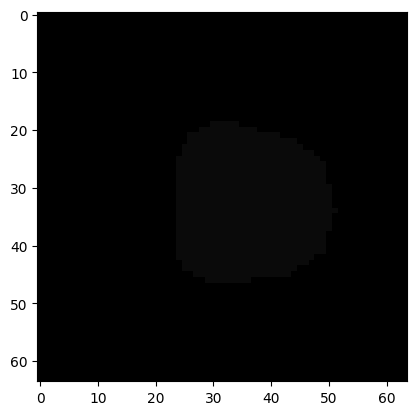

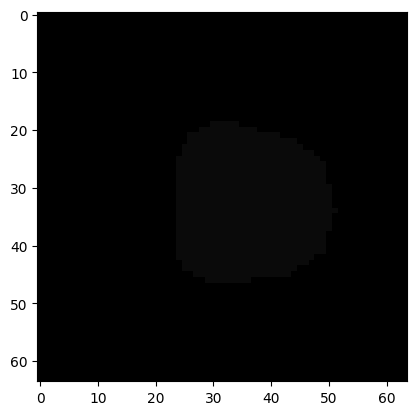

In [16]:
import cupy as cp
import numpy as np
from skimage.draw import polygon

def interpolate_triangle_value(p, v0, v1, v2, val0, val1, val2):
    """
    Interpolates the value of a point inside a triangle defined by its vertices and the values at those vertices.

    Args:
        p (numpy.ndarray): The point inside the triangle, given as a numpy array of length 2.
        v0 (numpy.ndarray): The first vertex of the triangle, given as a numpy array of length 2.
        v1 (numpy.ndarray): The second vertex of the triangle, given as a numpy array of length 2.
        v2 (numpy.ndarray): The third vertex of the triangle, given as a numpy array of length 2.
        val0 (float): The value at the first vertex of the triangle.
        val1 (float): The value at the second vertex of the triangle.
        val2 (float): The value at the third vertex of the triangle.

    Returns:
        float: The interpolated value at the given point inside the triangle.
    """
    # Compute the barycentric coordinates of p with respect to v0, v1, v2
    v1 = v1 - v0
    v2 = v2 - v0
    p = p - v0
    det = np.linalg.det(np.array([v1, v2]).T)
    barycentric_coords = np.linalg.inv(np.array([v1, v2]).T).dot(np.array([p]).T / det)
    
    # Interpolate the value at p using the barycentric coordinates
    return barycentric_coords[0, 0] * val0 + barycentric_coords[1, 0] * val1 + (1 - barycentric_coords[0, 0] - barycentric_coords[1, 0]) * val2


def replace_triangle_values(array, x1, y1, x2, y2, x3, y3, value):
    """
    Replaces the values of all elements inside a triangle with a given value.
    Assumes that the input array is a 2D CuPy array.
    """
    # Compute the bounding box of the triangle
    x_min, x_max = np.sort(np.asarray([x1, x2, x3])).min(), np.sort(np.asarray([x1, x2, x3])).max()
    y_min, y_max = np.sort(np.asarray([y1, y2, y3])).min(), np.sort(np.asarray([y1, y2, y3])).max()
    
    # Create a grid of indices inside the bounding box
    X, Y = np.meshgrid(np.arange(x_min, x_max+1), np.arange(y_min, y_max+1), indexing='ij')
    
    # Compute the barycentric coordinates of all the indices with respect to the triangle
    denom = (y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3)
    w1 = ((y2 - y3)*(X - x3) + (x3 - x2)*(Y - y3)) / denom
    w2 = ((y3 - y1)*(X - x3) + (x1 - x3)*(Y - y3)) / denom
    w3 = 1.0 - w1 - w2
    
    # Create a boolean mask for the indices inside the triangle
    mask = (w1 >= 0) & (w2 >= 0) & (w3 >= 0)
    
    # Use the mask to replace the values inside the triangle with the given value
    array[X[mask], Y[mask]] = value
    
    return array

def is_point_inside_triangle(point, v0, v1, v2):
    """
    Returns True if the given point is inside the triangle defined by its vertices.

    Args:
        point (numpy.ndarray): The point to check, given as a numpy array of length 2.
        v0 (numpy.ndarray): The first vertex of the triangle, given as a numpy array of length 2.
        v1 (numpy.ndarray): The second vertex of the triangle, given as a numpy array of length 2.
        v2 (numpy.ndarray): The third vertex of the triangle, given as a numpy array of length 2.

    Returns:
        bool: True if the point is inside the triangle, False otherwise.
    """
    # Compute the barycentric coordinates of the point with respect to the triangle
    v1 = v1 - v0
    v2 = v2 - v0
    p = point - v0
    det = np.linalg.det(np.array([v1, v2]).T)
    barycentric_coords = np.linalg.inv(np.array([v1, v2]).T).dot(np.array([p]).T / det)

    # Check if the barycentric coordinates are all between 0 and 1
    return (barycentric_coords[0, :] >= 0) & (barycentric_coords[1, :] >= 0) & (1 - barycentric_coords[0, :] - barycentric_coords[1, :] >= 0)


def points_inside_triangle(v0, v1, v2, shape=None):
    """
    Returns a numpy array of all the points inside a triangle defined by its vertices.

    Args:
        v0 (numpy.ndarray): The first vertex of the triangle, given as a numpy array of length 2.
        v1 (numpy.ndarray): The second vertex of the triangle, given as a numpy array of length 2.
        v2 (numpy.ndarray): The third vertex of the triangle, given as a numpy array of length 2.
        shape (tuple, optional): The shape of the output array. Defaults to None.

    Returns:
        numpy.ndarray: A numpy array of shape `shape` containing all the points inside the triangle.
    """
    # Get the bounding box of the triangle
    x_min = min(v0[0], v1[0], v2[0])
    x_max = max(v0[0], v1[0], v2[0])
    y_min = min(v0[1], v1[1], v2[1])
    y_max = max(v0[1], v1[1], v2[1])
    
    # Generate a grid of points within the bounding box
    if shape is None:
        shape = (int(y_max - y_min) + 1, int(x_max - x_min) + 1)
    X, Y = np.meshgrid(np.arange(x_min, x_max + 1), np.arange(y_min, y_max + 1))
    
    # Compute the barycentric coordinates of each point in the grid
    pts = np.vstack((X.flatten(), Y.flatten())).T
    v1 = v1 - v0
    v2 = v2 - v0
    p = pts - v0
    det = np.linalg.det(np.array([v1, v2]).T)
    barycentric_coords = np.linalg.inv(np.array([v1, v2]).T).dot(np.array([p]).T / det)
    
    # Keep only the points inside the triangle
    mask = (barycentric_coords[0, :] >= 0) & (barycentric_coords[1, :] >= 0) & (1 - barycentric_coords[0, :] - barycentric_coords[1, :] >= 0)
    return pts[mask].reshape(shape)

def compute_triangle_displacements(points_a, points_b, image_height=IMG_HEIGHT, image_width=IMG_WIDTH):
    """
    Computes the displacements of all points inside triangles defined by their vertices.
    Assumes that the input vertices and displacements are arrays of shape (num_triangles, 3, 2),
    where num_triangles is the number of triangles and each triangle is defined by three (x, y) vertex coordinates.
    Assumes that the input x and y are arrays of shape (height, width), representing the 2D grid of points to compute the displacements for.
    Returns an array of shape (height, width, 2), representing the displacements of each point on the grid.
    """
    triangles = Delaunay(points_a).simplices

    # convert to cupy
    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)
    triangles = np.asarray(triangles)

    # Compute the barycentric coordinates of all the points with respect to each triangle
    displacements_values = points_b - points_a
    displacements_values = displacements_values[triangles]

    displacements_map = np.zeros((image_height, image_width, 2), dtype=np.uint8)

    for i in range(triangles.shape[0]):
        # v0 = points_a[triangles[i, 0]]
        # v1 = points_a[triangles[i, 1]]
        # v2 = points_a[triangles[i, 2]]
        mean_value = np.mean(displacements_values[i], axis=0)
        cordinates = np.array(points_a[triangles[i]], dtype=np.int32)
        r, c = cordinates[..., 0], cordinates[..., 1]
        rr, cc = polygon(r, c)
        displacements_map[rr, cc] = mean_value
    # show both images with matplotlib
    plt.imshow(displacements_map[..., 0], cmap='gray', vmin=0, vmax=255)
    plt.show()
    plt.imshow(displacements_map[..., 1], cmap='gray', vmin=0, vmax=255)
    plt.show()
    

    return displacements_map

displacements_map = compute_triangle_displacements(out_landmarks[0], out_landmarks[0]+10)
# print(displacements_map.shape)
# print(displacements_map[0, 0])
# print(displacements_map[0, 1])
 



In [17]:
# @tf.function
# def whetherInTrianglesSpecial(triangle, p):
#     x1, y1, x2, y2, x3, y3 = tf.unstack(triangle, axis=0)

#     # Compute barycentric coordinates
#     denominator = (y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3)
#     alpha = ((y2 - y3) * (p[0] - x3) + (x3 - x2) * (p[1] - y3)) / denominator
#     beta = ((y3 - y1) * (p[0] - x3) + (x1 - x3) * (p[1] - y3)) / denominator
#     gamma = 1 - alpha - beta

#     # Check if point is inside triangle
#     is_inside = tf.logical_and(alpha >= 0, beta >= 0)
#     is_inside = tf.logical_and(is_inside, gamma >= 0)

#     return is_inside


# def interpolation(triangle, triangle_value, p):
#     x01 = p[0] - triangle[0]
#     x21 = triangle[2] - triangle[0]
#     x31 = triangle[4] - triangle[0]
#     y01 = p[1] - triangle[1]
#     y21 = triangle[3] - triangle[1]
#     y31 = triangle[5] - triangle[1]
#     tmp1 = x21 * y31 - y21 * x31
#     tmp2 = y31 * x21 - x31 * y21
#     u = (x01 * y31 - y01 * x31) / tmp1
#     v = (y01 * x21 - x01 * y21) / tmp2
#     q = 1.0 - u - v
#     value_out = q * triangle_value[0] + u * triangle_value[2] + v * triangle_value[4]
#     return value_out

# @tf.function
# def calcuDeformationMap(triangles, disps, triangle_size, map_width, map_height, batch_size, dispMap_out):
#     idx = tf.range(batch_size * map_width * map_height)
#     idx = tf.reshape(idx, (batch_size, map_height, map_width))
#     i_batch = tf.dtypes.cast(idx // (map_width * map_height), tf.int32)
#     i_h = tf.dtypes.cast(idx % map_height, tf.int32)
#     i_w = tf.dtypes.cast((idx // map_height) % map_width, tf.int32)
#     triangle = tf.range(triangle_size)
    
#     def loop_body(i_triangle, p0, index, triangles_cache, disps_cache):
#         triangle_index = 6 * (i_triangle + i_batch * triangle_size)
#         in_triangle = whetherInTrianglesSpecial(triangles_cache[triangle_index:triangle_index+6], p0)
#         mask = tf.cast(in_triangle, tf.bool)
#         indices = tf.boolean_mask(idx, mask)
#         indices = tf.reshape(indices, (-1, 1))
#         indices = tf.concat([indices // (map_width * map_height), indices % map_height, (indices // map_height) % map_width], axis=1)
#         u, v = interpolation(tf.expand_dims(triangles_cache[triangle_index:triangle_index+6], axis=0),
#                              tf.expand_dims(disps_cache[triangle_index:triangle_index+6], axis=0),
#                              tf.expand_dims(p0, axis=0))
#         value_out = tf.stack([1 - u - v, u, v], axis=1) @ tf.reshape(disps_cache[triangle_index:triangle_index+6], (3, 2))
#         dispMap_out = tf.tensor_scatter_nd_update(dispMap_out, indices, tf.reshape(value_out, (-1,)))
#         return i_triangle + 1, p0, index, triangles_cache, disps_cache
    
#     triangles_cache = tf.Variable(tf.zeros((6,), dtype=tf.float32), trainable=False)
#     disps_cache = tf.Variable(tf.zeros((6,), dtype=tf.float32), trainable=False)
#     def update_cache(i_triangle):
#         triangles_cache.assign(triangles[i_triangle * 6:(i_triangle + 1) * 6])
#         disps_cache.assign(disps[i_triangle * 6:(i_triangle + 1) * 6])
#         return triangles_cache, disps_cache
    
#     i_triangle = tf.constant(0, dtype=tf.int32)
#     p0 = tf.stack([tf.cast(i_w, tf.float32), tf.cast(i_h, tf.float32)], axis=1)
#     index = i_batch * map_width * map_height + i_h * map_width + i_w
#     _, _, _, _, _ = tf.while_loop(
#         lambda i, p0, index, triangles_cache, disps_cache: tf.less(i, triangle_size),
#         loop_body,
#         [i_triangle, p0, index, triangles_cache, disps_cache],
#         shape_invariants=[tf.TensorShape(()), tf.TensorShape((None, 2)), tf.TensorShape(()), tf.TensorShape((6,)), tf.TensorShape((6,))],
#         back_prop=False,
#     )
